In [31]:
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import pandas as pd

import sys
sys.path.append('../')
from src.option import Option
from src.kalman_filter import KalmanFilter

In [30]:
import importlib
importlib.reload(sys.modules['src.option'])

<module 'src.option' from 'c:\\Users\\wfpin\\Desktop\\Projects\\greeks\\notebooks\\..\\src\\option.py'>

In [32]:
S = 100; T = 5; r = 0.02; K = 100; sigma = 0.3
opt0 = Option(S, T, r, K, sigma)
market_price = opt0.black_scholes()
iv_bisection = opt0.implied_vol_bisection(market_price=market_price)
iv_newton = opt0.implied_vol_newton(market_price=market_price)
print(f'Implied volatility as estimated by the bisection method: {iv_bisection}')
print(f'Implied volatility as estimated by the Newton-Raphson method: {iv_newton}')
print(f'True implied volatility value: {opt0.sigma}')

Implied volatility as estimated by the bisection method: 0.3000000019720905
Implied volatility as estimated by the Newton-Raphson method: 0.29999999999999954
True implied volatility value: 0.3


In [33]:
iv_newton = opt0.implied_vol_newton(market_price=market_price, initial_guess=0.01)
print(f'Implied volatility as estimated by the Newton-Raphson method: {iv_newton}')

Implied volatility as estimated by the Newton-Raphson method: 5328.751737300914


The output from the last 2 cells is interesting because it highlights one of the weaknesses of the $Newton$-$Raphson$ method. It requires a relatively local guess of what the true implied volatility is. Otherwise, the method makes too large of a jump and completely misses the true value. This explains why, in practice, some combination of the 2 is used where the $Newton$-$Raphson$ method is used if its guess falls within some safe bound and defaults to the bisection method if necessary.

The following plot highlights the difference in efficiency. The $Newton$-$Raphson$ method cut off, the method clearly converged to the true value before the bisection method was able to. It not only cut off sooner, indicating that the difference in values fell within the acceptable tolerance sooner, but it also made predictions closer to the true value quicker.

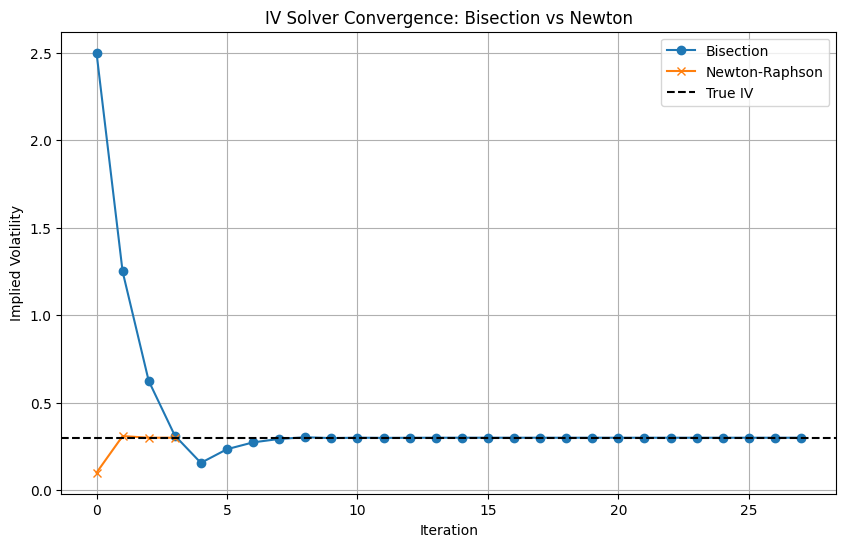

In [34]:
def plot_iv_convergence(option, market_price):

    bis_path = option.implied_vol_bisection(
        market_price, return_path=True
    )

    newton_path = option.implied_vol_newton(
        market_price, initial_guess=0.1, return_path=True
    )

    true_iv = option.sigma

    plt.figure(figsize=(10,6))

    # iteration indices
    plt.plot(bis_path, label='Bisection', marker='o')
    plt.plot(newton_path, label='Newton-Raphson', marker='x')

    # true value line
    plt.axhline(true_iv, linestyle='--', color='black', label='True IV')

    plt.xlabel('Iteration')
    plt.ylabel('Implied Volatility')
    plt.title('IV Solver Convergence: Bisection vs Newton')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_iv_convergence(option=opt0, market_price=market_price)

Here, I had the idea to test modeling implied volatility using a Kalman Filter that I had learned about in my time series econometrics class. The Kalman Filter, assumes some hidden state that it estimates using noisy, realized observations. In the case of an option's implied volatility, the true value would be the state, and the realized implied volatility is the value we observe distrorted by supply and demand dynamics that exist within the market price. 

In [72]:
# Due to an inability to access real options data, I construct a synthetic options chain from real data
spy = yf.download('SPY', period='6mo')
spy = spy.dropna()
spy

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2025-12-29,684.213867,685.556767,682.443308,683.905508,62559500
2025-12-30,683.378296,684.920090,682.950576,683.815972,47160700
2025-12-31,678.315247,683.726492,678.106396,683.507684,74144800
2026-01-02,679.558594,683.239047,676.226327,682.085206,89377200
2026-01-05,684.084595,685.785577,682.751712,682.910840,71927200
...,...,...,...,...,...
2026-06-22,744.390015,750.179993,743.130005,747.700012,46628100
2026-06-23,733.580017,739.630005,732.299988,733.809998,66846800


In [92]:
S0 = spy['Close']['SPY']
K = S0.iloc[0]  # ATM strike fixed
r = 0.01
# T_series = np.linspace(30/365, 1/365, len(S0))

In [93]:
# Assume a hidden volatilty process
true_vol = 0.20 + np.cumsum(np.random.normal(0, 0.002, len(S0)))
true_vol = np.clip(true_vol, 0.05, 0.8)

In [98]:
# Generate options prices
prices = []

for i in range(len(S0)):
    S = S0.iloc[i]

    price = Option(S, 30/365, r, K, true_vol[i], 'call').black_scholes()

    # force scalar noise
    noise = float(np.random.normal(0, 0.1))

    price = float(price + noise)

    prices.append(price)

In [100]:
# Compute the implied volatility series
iv_series = []

for i in range(len(S0)):
    S = S0.iloc[i]
    price = prices[i]

    iv = Option(S, 30/365, r, K, None, 'call').implied_vol(market_price=price)
    iv_series.append(iv)

iv_series = np.array(iv_series)

In [101]:
# Declare Kalman Filter parameters
F = np.array([[1.]])   # random walk volatility
Z = np.array([[1.]])   # IV observed directly

Q = np.array([[1e-5]]) # process noise (vol changes slowly)
R = np.array([[1e-3]]) # IV observation noise

x0 = np.array([[iv_series[0]]])
P0 = np.array([[1.0]])

kf = KalmanFilter(F=F, Z=Z, Q=Q, eps=R, P=P0, x0=x0)

In [102]:
# Run path
kf_path = []

for z in iv_series:
    kf.predict()
    kf.update(np.array([[z]]))
    kf_path.append(kf.x[0,0])

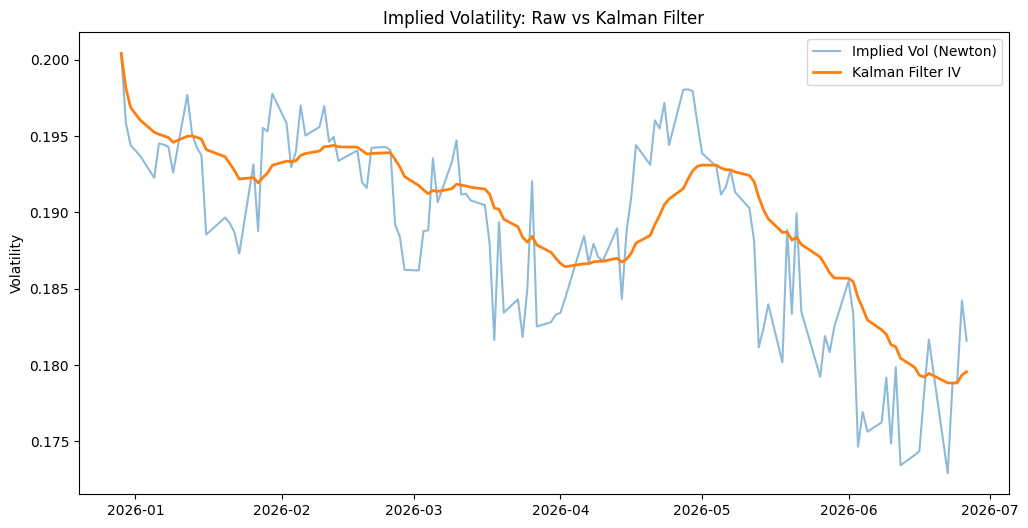

In [106]:
# Plot
plt.figure(figsize=(12,6))

plt.plot(S0.index, iv_series, label="Implied Vol (Newton)", alpha=0.5)
plt.plot(S0.index, kf_path, label="Kalman Filter IV", linewidth=2)

plt.title("Implied Volatility: Raw vs Kalman Filter")
plt.ylabel("Volatility")
plt.legend()
plt.show()